In [5]:
import pandapower as pp
import pandapower.networks as nw
from copy import deepcopy
import pandapower.plotting as plot
import numpy as np
import pandas as pd
import os
import numba

import julia
julia.install()

from julia.api import Julia
jl = Julia(compiled_modules=False)

import warnings
warnings.filterwarnings('ignore')


[ Info: Julia version info


Julia Version 1.6.0
Commit f9720dc2eb (2021-03-24 12:55 UTC)
Platform Info:
  OS: Linux (x86_64-pc-linux-gnu)
      "Manjaro Linux"
  uname: Linux 6.6.30-2-MANJARO #1 SMP PREEMPT_DYNAMIC Wed May  8 17:46:43 UTC 2024 x86_64 unknown
  CPU: 13th Gen Intel(R) Core(TM) i5-13400F: 
                 speed         user         nice          sys         idle          irq
       #1-16  4500 MHz    2359926 s        433 s     214750 s   41411733 s      18224 s
       
  Memory: 62.63358688354492 GB (2026.8984375 MB free)
  Uptime: 275631.0 sec
  Load Avg:  2.22  3.72  4.72
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-11.0.1 (ORCJIT, goldmont)
Environment:
  HOME = /home/iboero
  PATH = /home/iboero/miniconda3/envs/proy/bin:/home/iboero/.vscode-server/cli/servers/Stable-dc96b837cf6bb4af9cd736aa3af08cf8279f7685/server/bin/remote-cli:/home/iboero/miniconda3/envs/proy/bin:/home/iboero/miniconda3/condabin:/home/iboero/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/bin:/opt/cuda/bin:/opt/cuda/nsi

[ Info: Julia executable: /home/iboero/julia/bin/julia
[ Info: Trying to import PyCall...
┌ Info: PyCall is already installed and compatible with Python executable.
│ 
│ PyCall:
│     python: /home/iboero/miniconda3/envs/proy/bin/python
│     libpython: /home/iboero/miniconda3/envs/proy/lib/libpython3.11.so.1.0
│ Python:
│     python: /home/iboero/miniconda3/envs/proy/bin/python
└     libpython: 


## Pruebas sobre la red creada

In [57]:
# Levantar red
net = pp.from_pickle('red_uru.p')

gen_p = pd.read_csv("./crudo/GENP_total_pandapower.csv")
load_p = pd.read_csv("./crudo/LOADP_total_pandapower.csv")

index = 261

gen_idx = net.gen.bus.values.astype(str)
shunt_idx = net.sgen.loc[net.sgen.controllable==True].bus.values.astype(str)
sgen_idx = net.sgen.loc[net.sgen.controllable==False].bus.values.astype(str)
load_idx = net.load.bus.values.astype(str)

net.gen.p_mw = gen_p.loc[index,gen_idx].values
net.load.p_mw = load_p.loc[index,load_idx].values 
net.load.q_mvar = load_p.loc[index,load_idx].values* np.tan(np.arccos(0.92)) 
net.sgen.loc[net.sgen.controllable==False].p_mw = gen_p.loc[index,sgen_idx].values

net.gen.max_p_mw = net.gen.p_mw 
net.gen.min_p_mw = net.gen.p_mw

# net.line.c_nf_per_km /= 2

In [47]:
print("Total Load " , net.load.p_mw.sum())

pp.runpp(net,enforce_q_lims=True)
v_org = net.res_bus.vm_pu.values
display(sum(abs(v_org-1)))

netoptv = deepcopy(net)
netoptv.bus["pm_param/setpoint_v"] = 1.0
pp.runpm_vstab(netoptv)
v_opt = netoptv.res_bus.vm_pu.values
display(sum(abs(v_opt-1))) 



Total Load  1010.7127795950001


1.165793740283824

no costs are given - overall generated power is minimized


1.2189329259376782

In [48]:
print(netoptv.res_sgen.q_mvar[:7].values.astype(int))

[-77 -69 -39 -32 -59   0   0]



## Generamos los datos y los guardamos en un npy

In [17]:
# Levantar red
net = pp.from_pickle('red_uru.p')

net.line.c_nf_per_km /= 3
net.bus["pm_param/setpoint_v"] = 1.0

gen_p = pd.read_csv("./crudo/GENP_total_pandapower.csv")
load_p = pd.read_csv("./crudo/LOADP_total_pandapower.csv")

# Create a map from net.bus.index to the position of the bues
bus_map = {net.bus.index[i]: i for i in range(len(net.bus))}


# That also works for a list of buses
def bus_pos(buses):
    try:
        return [bus_map[bus] for bus in buses]
    except:
        return bus_map[buses]



# Empezar a generar datos

X = []
Y_volt = []
Y_react = []
Y_switch_shunts = []
# Dividir en 10 batches de 1000 datos
for index in range(1):
  
  y_volt = np.zeros((len(net.bus["name"]),1))
  y_react = np.zeros((len(net.bus["name"]),1))
  y_switch_shunts  = np.zeros((len(net.bus["name"]),1))
  X_i = np.zeros((len(net.bus["name"]),4))
  print('iteracion:', index)


  gen_idx = net.gen.bus.values.astype(str)
  shunt_idx = net.sgen.loc[net.sgen.controllable==True].bus.values.astype(str)
  sgen_idx = net.sgen.loc[net.sgen.controllable==False].bus.values.astype(str)
  load_idx = net.load.bus.values.astype(str)

  net.gen.p_mw = gen_p.loc[index,gen_idx].values
  net.load.p_mw = load_p.loc[index,load_idx].values 
  # Samplear normal para el coseno de phi por carga:
  coef_p = np.random.normal(0.9, 0.02, len(load_idx)).clip(0,1)
  net.load.q_mvar = load_p.loc[index,load_idx].values * np.tan(np.arccos(coef_p)) 
  net.sgen.p_mw.loc[net.sgen.controllable==False] = gen_p.loc[index,sgen_idx].values
  print(gen_p.loc[index,sgen_idx].values)
  print(net.sgen.loc[net.sgen.controllable==False].p_mw)
  net.gen.max_p_mw = net.gen.p_mw 
  net.gen.min_p_mw = net.gen.p_mw

  # Rellenar X
  X_i[bus_pos(net.gen.bus.values)] += np.array([np.zeros(len(net.gen.p_mw)), np.zeros(len(net.gen.p_mw)),net.gen.p_mw.values.astype('float64'), np.zeros(len(net.gen.p_mw))]).T
  X_i[bus_pos(net.load.bus.values)] += np.array([net.load.p_mw.values.astype('float64'), net.load.q_mvar.values.astype('float64'), np.zeros(len(net.load.q_mvar)), np.zeros(len(net.load.q_mvar))]).T
  X_i[bus_pos(net.sgen.bus.loc[net.sgen.controllable==False].values)] += np.array([np.zeros(len(net.sgen.loc[net.sgen.controllable==False].p_mw)), np.zeros(len(net.sgen.loc[net.sgen.controllable==False].p_mw)), np.zeros(len(net.sgen.loc[net.sgen.controllable==False].p_mw)),net.sgen.p_mw.loc[net.sgen.controllable==False].values.astype('float64')]).T

  # Resolver OPF
  try:
    pp.runpm_vstab(net)
    #Rellenar y
    y_volt[bus_pos(net.gen.bus.values)] = net.res_gen.vm_pu.values.reshape(-1,1)
    y_react[bus_pos(net.gen.bus.values)] = net.res_gen.q_mvar.values.reshape(-1,1)
    y_switch_shunts[bus_pos(net.sgen.bus.loc[net.sgen.controllable==True].values)] = net.res_sgen.loc[net.sgen.controllable==True].q_mvar.values.reshape(-1,1)
    Y_volt.append(y_volt)
    Y_react.append(y_react)
    Y_switch_shunts.append(y_switch_shunts)
    X.append(X_i)
  except:
    print("no convergio")




no costs are given - overall generated power is minimized


iteracion: 0
[0.0 0.0 0.0 0.0 0.0 24.439 0.0 3.72 62.664 0.395 1.201 0.023 2.208 30.184
 5.037 105.093 4.385 9.696 12.976 0.0 42.611 7.545 10.78 52.17699999999999
 19.888]
6         0.0
7         0.0
8         0.0
9         0.0
10        0.0
11     24.439
12        0.0
13       3.72
14     62.664
15      0.395
16      1.201
17      0.023
18      2.208
19     30.184
20      5.037
21    105.093
22      4.385
23      9.696
24     12.976
25        0.0
26     42.611
27      7.545
28      10.78
29     52.177
30     19.888
Name: p_mw, dtype: object


In [21]:
net.trafo

,name,std_type,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,i0_percent,shift_degree,tap_side,tap_neutral,tap_min,tap_max,tap_step_percent,tap_step_degree,tap_pos,tap_phase_shifter,parallel,df,in_service,vector_group,max_loading_percent
0,None,None,90000,92000,120.0,500.0,150.0,10.654304,0.179,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
1,None,None,90000,92000,256.0,500.0,150.0,6.591885,0.108,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
2,None,None,90080,92080,150.0,500.0,150.0,10.533086,0.358,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
3,None,None,90100,92100,425.0,500.0,150.0,2.227324,0.038,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
4,None,None,90100,92100,425.0,500.0,150.0,2.158289,0.151,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
5,None,None,90200,92200,425.0,500.0,150.0,2.930316,0.043,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
6,None,None,90200,92200,425.0,500.0,150.0,2.945384,0.178,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
7,None,None,90300,92300,271.7,500.0,150.0,4.534019,0.013,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
8,None,None,90300,92300,271.7,500.0,150.0,4.534019,0.013,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0
9,None,None,90480,92480,250.0,500.0,150.0,6.901350,0.215,0.0,0.0,0.0,None,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1.0,True,' ',100.0


In [3]:
## Generar data unico

import numpy as np
import matplotlib.pyplot as plt

# List of .npy files to merge
path = './reduru/'

file_list_input = [f'input_{i}.0.npy' for i in range(1,24)]
file_list_q = [f'q_mvar_opt_{i}.0.npy' for i in range(1,24)]
file_list_q_shunt = [f'q_switch_shunt_opt_{i}.0.npy' for i in range(1,24)]
file_list_vm_pu = [f'vm_pu_opt_{i}.0.npy' for i in range(1,24)]

# Load the first file to initialize the merged array
input_list = []
q_list = []
q_shunt_list = []
vm_pu_list = []


# Iterate over the remaining files and concatenate them to the merged array
for idx,file in enumerate(file_list_input):
    input_list.append(np.load(path+file))
    q_list.append(np.load(path+file_list_q[idx]))
    q_shunt_list.append(np.load(path+file_list_q_shunt[idx]))
    vm_pu_list.append(np.load(path+file_list_vm_pu[idx]))

merged_input = np.concatenate(input_list, axis=0)
merged_q = np.concatenate(q_list, axis=0)
merged_q_shunt = np.concatenate(q_shunt_list, axis=0)
merged_vm_pu = np.concatenate(vm_pu_list, axis=0)

# Print shape of each array
print(merged_input.shape)
print(merged_q.shape)
print(merged_q_shunt.shape)
print(merged_vm_pu.shape)

# Save the merged array to a new .npy file
np.save(path+'input.npy', merged_input)
np.save(path+'q_mvar_opt.npy', merged_q)
np.save(path+'q_switch_shunt_opt.npy', merged_q_shunt)
np.save(path+'vm_pu_opt.npy', merged_vm_pu)


(19086, 107, 4)
(19086, 107, 1)
(19086, 107, 1)
(19086, 107, 1)


In [3]:
Y_switch_shunts.squeeze()[0]

NameError: name 'Y_switch_shunts' is not defined

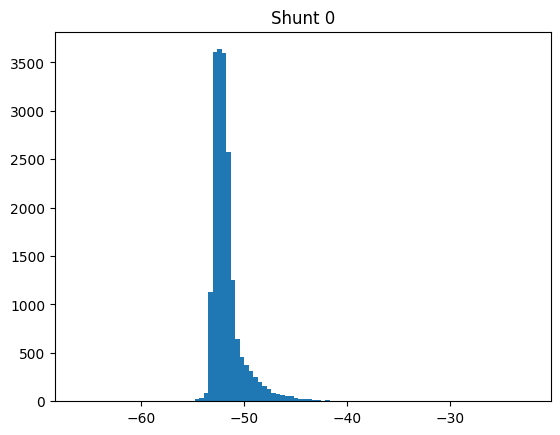

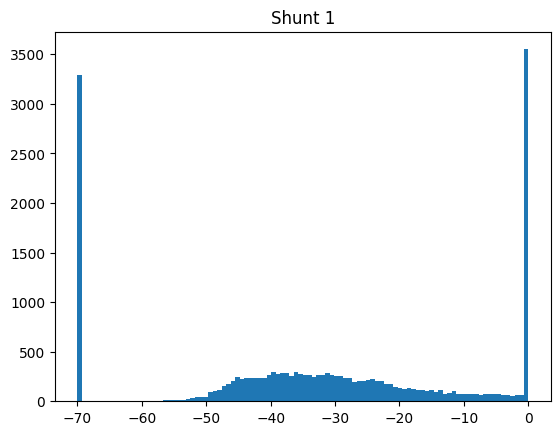

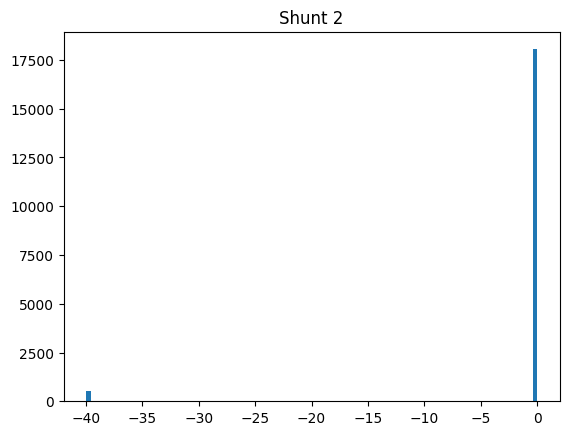

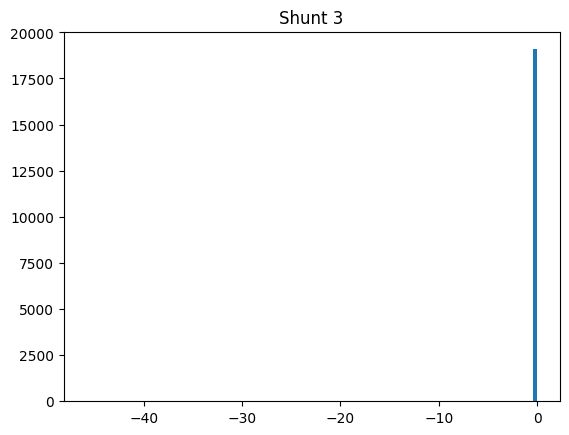

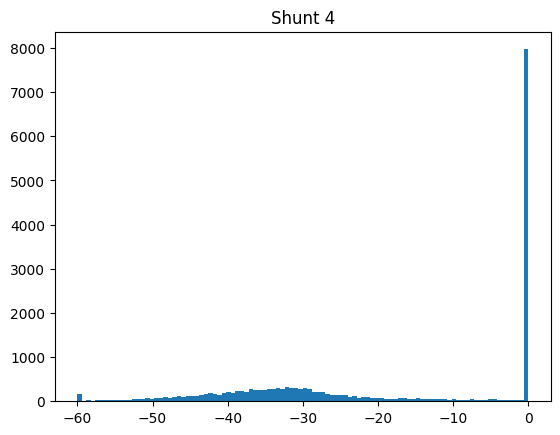

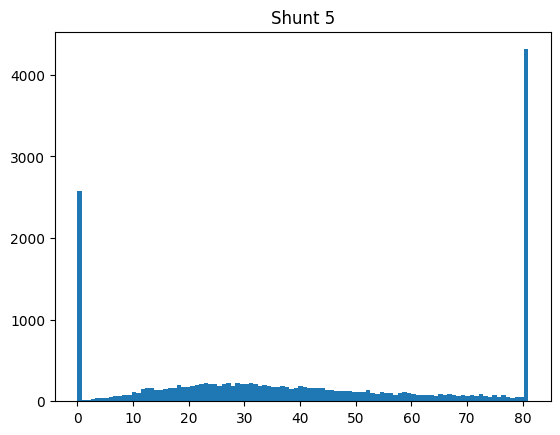

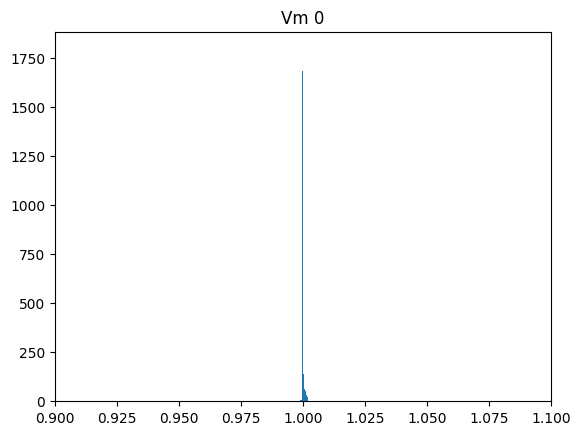

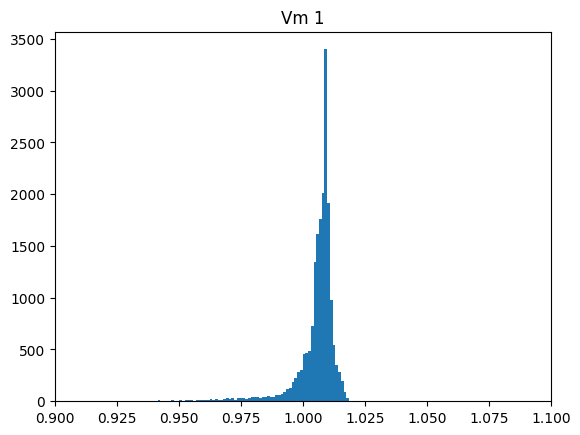

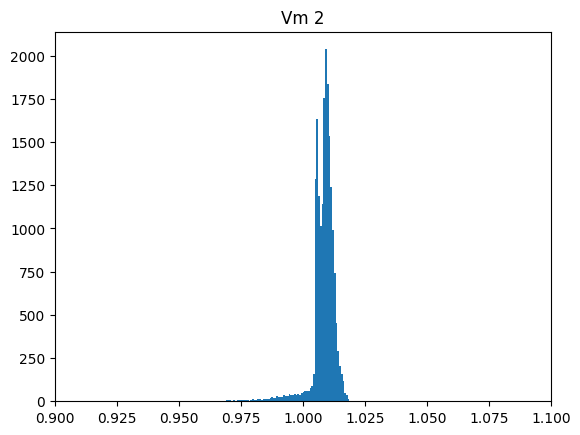

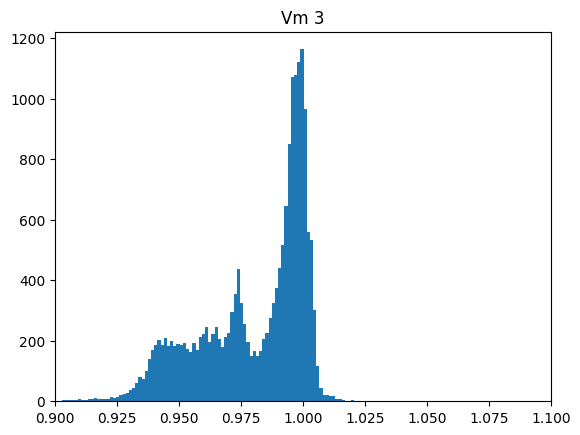

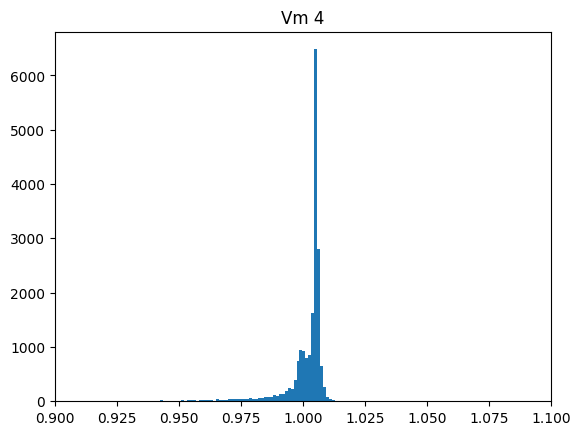

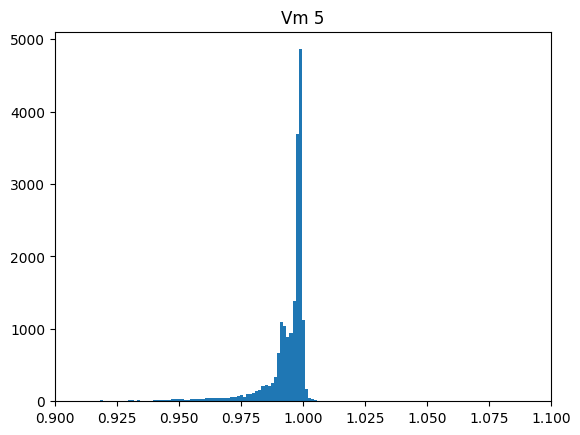

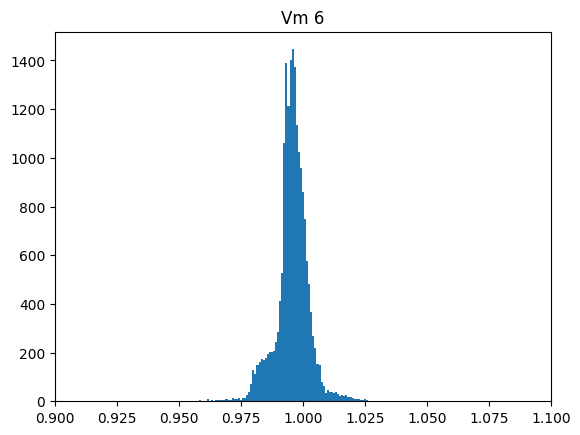

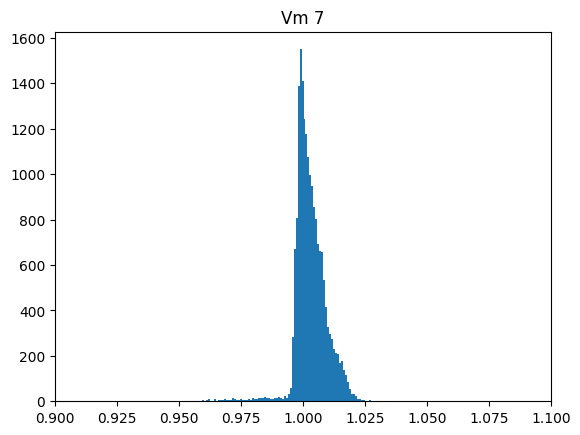

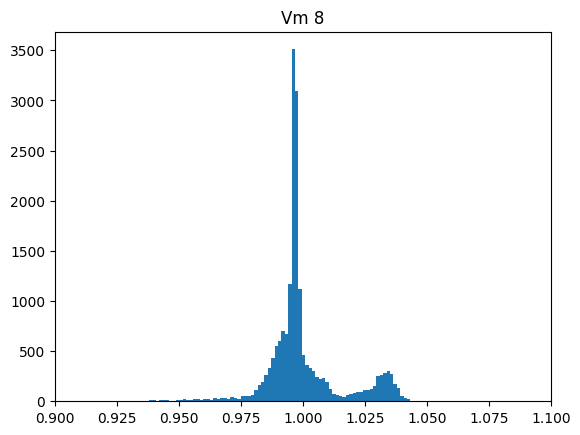

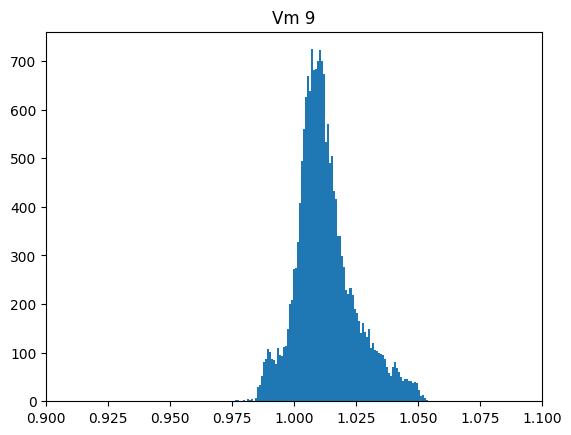

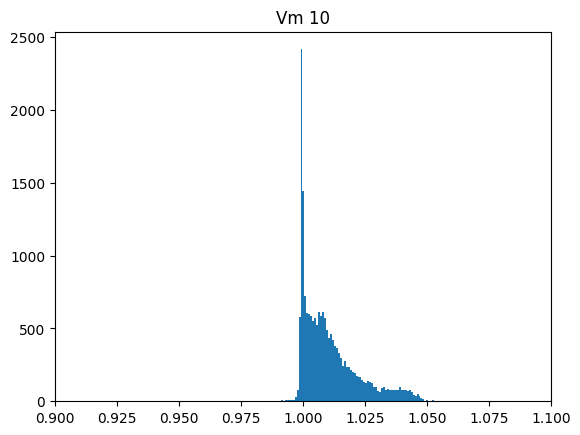

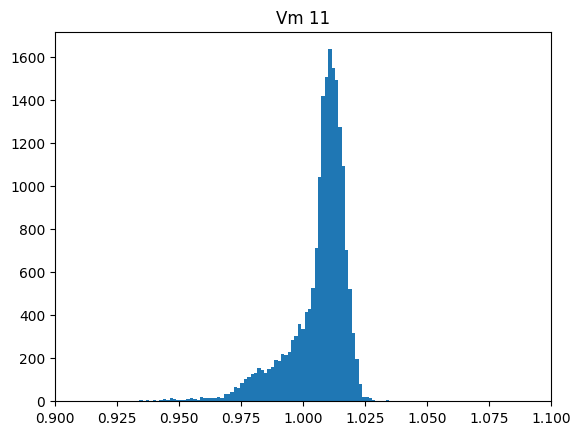

In [4]:
# Levantar los datos
net = pp.from_pickle('red_uru.p')
net.line.c_nf_per_km /= 3


bus_map = {net.bus.index[i]: i for i in range(len(net.bus))}
def bus_pos(buses):
    try:
        return [bus_map[bus] for bus in buses]
    except:
        return bus_map[buses]
    
X = np.load('./uru/input.npy')
Y_vm_pu = np.load('./uru/vm_pu_opt.npy')
Y_switch_shunts = np.load('./uru/q_switch_shunt_opt.npy')

y_switchs_analisis = Y_switch_shunts.squeeze()[:, bus_pos(net.sgen.bus.loc[net.sgen.controllable==True].values)]
vm_pu_analisis = Y_vm_pu.squeeze()[:, bus_pos(net.gen.bus.values)]

import matplotlib.pyplot as plt

for i in range(y_switchs_analisis.shape[1]):
  plt.hist(y_switchs_analisis[:,i], bins=100)
  plt.title("Shunt " + str(i))
  plt.show()

for i in range(vm_pu_analisis.shape[1]):
  plt.hist(vm_pu_analisis[:,i], bins=100)
  plt.xlim(0.9,1.1)
  plt.title("Vm " + str(i))
  plt.show()